<style>.day5-card{background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}.day5-card p,.day5-card li,.day5-card td{color:#111111!important;}.day5-card table{width:100%;border-collapse:collapse;}.day5-card th{padding:9px;border:1px solid #CBD5E1;}.day5-card td{padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}</style>
<h1 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);text-align:center;font-weight:bold;padding:18px 12px;border-radius:10px;margin-bottom:7px;">Day 5 — Full Evaluation & Explainability</h1>
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">Credit Card Fraud Detection — Imbalance, Threshold Tuning & SHAP</h3>
<div style="border-left:6px solid #FB7185;background-color:#FFF1F2;padding:12px 16px;margin:16px 0;border-radius:6px;color:#7F1D1D;"><b>Week 8 — AI & ML Internship • Day 5</b><br>Dataset: <code>creditcard.csv</code></div>
<div class="day5-card"><p><b>Main question:</b></p><div style="font-size:1.12em;font-weight:bold;text-align:center;background-color:#FFFBEB;border:1px solid #FBBF24;padding:16px;border-radius:8px;margin:14px 0;color:#111827;">How do we evaluate an imbalanced fraud model correctly, tune its decision threshold, and explain why it makes a prediction?</div></div>

<a id="toc"></a><h2 style="color:#92400E;background-color:#FBBF24;font-weight:bold;margin-top:30px;padding:9px 14px;border-radius:7px;">Table of Contents</h2>
<div style="border:1px solid #CBD5E1;padding:16px 25px;border-radius:8px;background-color:#FFFFFF;color:#111827;"><ul style="font-weight:bold;line-height:1.95;color:#1F2937;">
<li><a href="#section0">0. Setup — Imports & Dataset Path</a></li><li><a href="#section1">1. Load & Understand the Fraud Dataset</a></li><li><a href="#section2">2. Why Accuracy Alone Is Not Enough</a></li><li><a href="#section3">3. Train a Baseline Model</a></li><li><a href="#section4">4. Full Classification Evaluation</a></li><li><a href="#section5">5. Handling Class Imbalance with SMOTE</a></li><li><a href="#section6">6. Compare Baseline vs. SMOTE</a></li><li><a href="#section7">7. Precision–Recall Trade-off</a></li><li><a href="#section8">8. Threshold Tuning</a></li><li><a href="#section9">9. SHAP Explainability</a></li><li><a href="#section10">10. Global Feature Importance</a></li><li><a href="#section11">11. Explain One Prediction</a></li><li><a href="#section12">12. Final Technical Summary</a></li><li><a href="#section13">13. What I Learned Today</a></li><li><a href="#section14">14. Day 5 Mental Map</a></li>
</ul></div>

<a id="section0"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">0. Setup — Imports & Dataset Path</h2>

<style>.day5-card{background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}.day5-card p,.day5-card li,.day5-card td{color:#111111!important;}.day5-card table{width:100%;border-collapse:collapse;}.day5-card th{padding:9px;border:1px solid #CBD5E1;}.day5-card td{padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}</style><div class="day5-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">0.1 Required libraries</h3><p>Main tools: <b>pandas, NumPy, scikit-learn, imbalanced-learn, SHAP, matplotlib</b>.</p><div style="border-left:5px solid #FBBF24;background-color:#FFFBEB;padding:11px 15px;margin:12px 0;border-radius:5px;color:#78350F;"><b>If needed:</b> run the next installation cell once inside Jupyter, then restart the kernel.</div></div>

In [1]:
# Run only if the packages are missing.
# %pip install imbalanced-learn shap

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    ConfusionMatrixDisplay, precision_recall_curve, roc_curve,
)

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except ModuleNotFoundError as error:
    raise ModuleNotFoundError('Install imbalanced-learn with: %pip install imbalanced-learn') from error

try:
    import shap
except ModuleNotFoundError as error:
    raise ModuleNotFoundError('Install SHAP with: %pip install shap') from error

SEED = 42
np.random.seed(SEED)
print('SHAP:', shap.__version__)

SHAP: 0.52.0


In [3]:
candidate_paths = [Path('creditcard.csv'), Path.cwd() / 'creditcard.csv', Path('/mnt/data/creditcard.csv')]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find creditcard.csv. Place it beside Day5.ipynb.")


<a id="section1"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">1. Load & Understand the Fraud Dataset</h2>

<style>.day5-card{background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}.day5-card p,.day5-card li,.day5-card td{color:#111111!important;}.day5-card table{width:100%;border-collapse:collapse;}.day5-card th{padding:9px;border:1px solid #CBD5E1;}.day5-card td{padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}</style><div class="day5-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">1.1 Target meaning</h3><div style="background-color:#CCFBF1;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas,monospace;font-size:.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:10px 0;">Class = 0 → Normal transaction
Class = 1 → Fraud transaction</div><p>The dataset is useful for Day 5 because the fraud class is much smaller than the normal class.</p></div>

In [4]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head())

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print('Missing values:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))
print('Columns:', df.columns.tolist())

Missing values: 0
Duplicate rows: 1081
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [6]:
class_counts = df['Class'].value_counts().sort_index()
class_percent = df['Class'].value_counts(normalize=True).sort_index() * 100
class_summary = pd.DataFrame({'count': class_counts, 'percentage': class_percent})
class_summary.index = ['Normal (0)', 'Fraud (1)']
display(class_summary)

,count,percentage
Normal (0),284315,99.827251
Fraud (1),492,0.172749


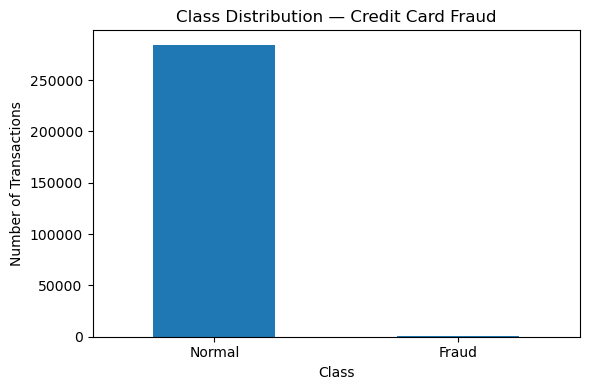

In [7]:
plt.figure(figsize=(6,4))
class_counts.plot(kind='bar')
plt.title('Class Distribution — Credit Card Fraud')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.xticks([0,1], ['Normal','Fraud'], rotation=0)
plt.tight_layout(); plt.show()

<style>.day5-card{background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}.day5-card p,.day5-card li,.day5-card td{color:#111111!important;}.day5-card table{width:100%;border-collapse:collapse;}.day5-card th{padding:9px;border:1px solid #CBD5E1;}.day5-card td{padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}</style><div class="day5-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">1.2 Class imbalance</h3><div style="background-color:#FFF7ED;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas,monospace;font-size:.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:10px 0;">Normal transactions → very many
Fraud transactions  → very few</div><div style="border-left:5px solid #FBBF24;background-color:#FFFBEB;padding:11px 15px;margin:12px 0;border-radius:5px;color:#78350F;"><b>Important:</b> a high accuracy score can still hide a weak fraud detector.</div></div>

<a id="section2"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">2. Why Accuracy Alone Is Not Enough</h2>

<style>.day5-card{background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}.day5-card p,.day5-card li,.day5-card td{color:#111111!important;}.day5-card table{width:100%;border-collapse:collapse;}.day5-card th{padding:9px;border:1px solid #CBD5E1;}.day5-card td{padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}</style><div class="day5-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">2.1 A misleading example</h3><p>If a model predicts almost everything as normal, accuracy may look excellent while fraud recall is terrible.</p><div style="background-color:#FFF7ED;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas,monospace;font-size:.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:10px 0;">Very high Accuracy
BUT
Fraud Recall ≈ 0</div><table><tr style="background-color:#0F766E;color:white;"><th style="color:white;">Metric</th><th style="color:white;">What it tells us</th></tr><tr><td><b>Precision</b></td><td>Of predicted frauds, how many were really fraud?</td></tr><tr><td><b>Recall</b></td><td>Of all real frauds, how many did we catch?</td></tr><tr><td><b>F1</b></td><td>Balance between precision and recall.</td></tr><tr><td><b>ROC-AUC</b></td><td>Ranking quality across thresholds.</td></tr><tr><td><b>PR-AUC</b></td><td>Positive-class performance under imbalance.</td></tr></table></div>

<a id="section3"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">3. Train a Baseline Model</h2>

<style>.day5-card{background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}.day5-card p,.day5-card li,.day5-card td{color:#111111!important;}.day5-card table{width:100%;border-collapse:collapse;}.day5-card th{padding:9px;border:1px solid #CBD5E1;}.day5-card td{padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}</style><div class="day5-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">3.1 Train / test split</h3><p>We split first, then keep the test set untouched.</p><div style="border-left:5px solid #FBBF24;background-color:#FFFBEB;padding:11px 15px;margin:12px 0;border-radius:5px;color:#78350F;"><b>Data leakage rule:</b> never apply SMOTE before the train/test split.</div></div>

In [8]:
X = df.drop(columns='Class')
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED, stratify=y)
print('Training:', X_train.shape, 'Test:', X_test.shape)
print('Fraud in train:', int(y_train.sum()), 'Fraud in test:', int(y_test.sum()))

Training: (227845, 30) Test: (56962, 30)
Fraud in train: 394 Fraud in test: 98


<style>.day5-card{background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}.day5-card p,.day5-card li,.day5-card td{color:#111111!important;}.day5-card table{width:100%;border-collapse:collapse;}.day5-card th{padding:9px;border:1px solid #CBD5E1;}.day5-card td{padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}</style><div class="day5-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">3.2 Local baseline</h3><p>We use <b>StandardScaler + LogisticRegression</b> as a simple reference model.</p><div style="border-left:5px solid #FBBF24;background-color:#FFFBEB;padding:11px 15px;margin:12px 0;border-radius:5px;color:#78350F;"><b>Curriculum note:</b> the source asks for comparison against the Week 6 baseline. That saved baseline is not provided here, so this notebook creates a local baseline on the fraud dataset for a valid technical comparison.</div></div>

In [9]:
baseline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=SEED)),
])
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)
baseline_prob = baseline_model.predict_proba(X_test)[:,1]
print('Baseline trained.')

Baseline trained.


<a id="section4"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">4. Full Classification Evaluation</h2>

In [10]:
def evaluate_predictions(y_true, y_pred, y_prob, model_name):
    return pd.DataFrame([{
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'PR-AUC': average_precision_score(y_true, y_prob),
    }])

In [11]:
baseline_metrics = evaluate_predictions(y_test, baseline_pred, baseline_prob, 'Baseline')
display(baseline_metrics.style.format({c:'{:.4f}' for c in baseline_metrics.columns if c != 'Model'}))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline,0.9991,0.8267,0.6327,0.7168,0.9605,0.7414


In [12]:
print(classification_report(y_test, baseline_pred, target_names=['Normal','Fraud'], digits=4, zero_division=0))

              precision    recall  f1-score   support

      Normal     0.9994    0.9998    0.9996     56864
       Fraud     0.8267    0.6327    0.7168        98

    accuracy                         0.9991     56962
   macro avg     0.9130    0.8162    0.8582     56962
weighted avg     0.9991    0.9991    0.9991     56962



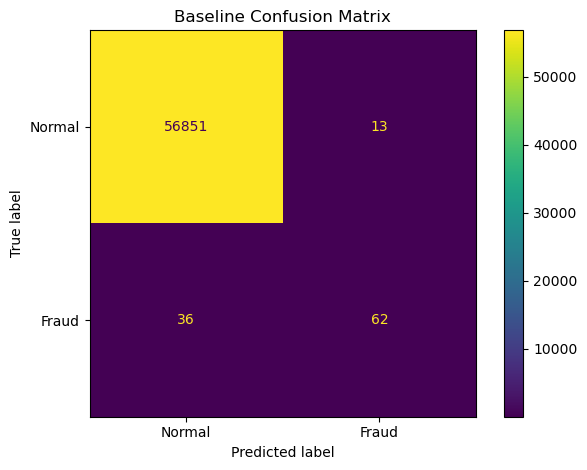

In [13]:
ConfusionMatrixDisplay.from_predictions(y_test, baseline_pred, display_labels=['Normal','Fraud'], values_format='d')
plt.title('Baseline Confusion Matrix'); plt.tight_layout(); plt.show()

<a id="section5"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">5. Handling Class Imbalance with SMOTE</h2>

<style>.day5-card{background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}.day5-card p,.day5-card li,.day5-card td{color:#111111!important;}.day5-card table{width:100%;border-collapse:collapse;}.day5-card th{padding:9px;border:1px solid #CBD5E1;}.day5-card td{padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}</style><div class="day5-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">5.1 What is SMOTE?</h3><p><b>SMOTE — Synthetic Minority Over-sampling Technique</b> creates synthetic minority-class training examples.</p><div style="background-color:#CCFBF1;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas,monospace;font-size:.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:10px 0;">Training data
   ↓
Scale
   ↓
SMOTE
   ↓
Classifier</div><div style="border-left:5px solid #FBBF24;background-color:#FFFBEB;padding:11px 15px;margin:12px 0;border-radius:5px;color:#78350F;"><b>Critical rule:</b> SMOTE is applied to training data only. The test set stays real and untouched.</div></div>

In [14]:
smote_model = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=SEED)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=SEED)),
])
smote_model.fit(X_train, y_train)
smote_pred = smote_model.predict(X_test)
smote_prob = smote_model.predict_proba(X_test)[:,1]
print('SMOTE model trained.')

SMOTE model trained.


In [15]:
scaler_preview = StandardScaler()
X_train_scaled_preview = scaler_preview.fit_transform(X_train)
_, y_resampled = SMOTE(random_state=SEED).fit_resample(X_train_scaled_preview, y_train)
summary = pd.DataFrame({'Before SMOTE': y_train.value_counts().sort_index(), 'After SMOTE': pd.Series(y_resampled).value_counts().sort_index()})
summary.index = ['Normal (0)','Fraud (1)']
display(summary)

,Before SMOTE,After SMOTE
Normal (0),227451,227451
Fraud (1),394,227451


<a id="section6"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">6. Compare Baseline vs. SMOTE</h2>

In [16]:
smote_metrics = evaluate_predictions(y_test, smote_pred, smote_prob, 'SMOTE')
comparison = pd.concat([baseline_metrics, smote_metrics], ignore_index=True)
display(comparison.style.format({c:'{:.4f}' for c in comparison.columns if c != 'Model'}))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline,0.9991,0.8267,0.6327,0.7168,0.9605,0.7414
1,SMOTE,0.9741,0.0578,0.9184,0.1088,0.9708,0.7245


<style>.day5-card{background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}.day5-card p,.day5-card li,.day5-card td{color:#111111!important;}.day5-card table{width:100%;border-collapse:collapse;}.day5-card th{padding:9px;border:1px solid #CBD5E1;}.day5-card td{padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}</style><div class="day5-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">6.1 Read the trade-off</h3><p>SMOTE does not guarantee every metric improves. A common outcome is higher recall with lower precision.</p><div style="background-color:#FFF7ED;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas,monospace;font-size:.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:10px 0;">Higher Recall ↔ Possible Lower Precision</div></div>

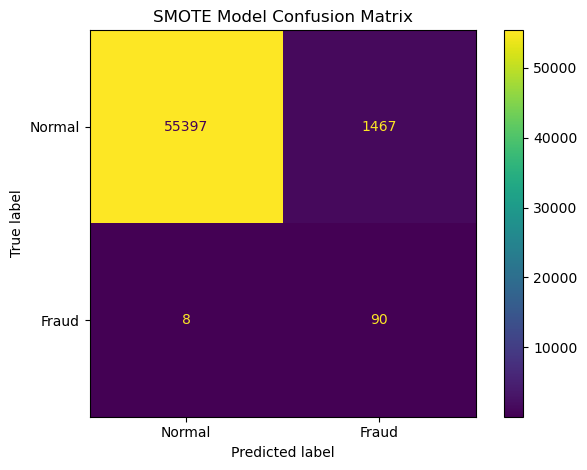

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, smote_pred, display_labels=['Normal','Fraud'], values_format='d')
plt.title('SMOTE Model Confusion Matrix'); plt.tight_layout(); plt.show()

<a id="section7"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">7. Precision–Recall Trade-off</h2>

<style>.day5-card{background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}.day5-card p,.day5-card li,.day5-card td{color:#111111!important;}.day5-card table{width:100%;border-collapse:collapse;}.day5-card th{padding:9px;border:1px solid #CBD5E1;}.day5-card td{padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}</style><div class="day5-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">7.1 Threshold meaning</h3><div style="background-color:#E0F2FE;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas,monospace;font-size:.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:10px 0;">Fraud probability = 0.82, threshold = 0.50 → Fraud
Fraud probability = 0.42, threshold = 0.50 → Normal</div><p>Lowering the threshold usually catches more fraud but may increase false alarms.</p></div>

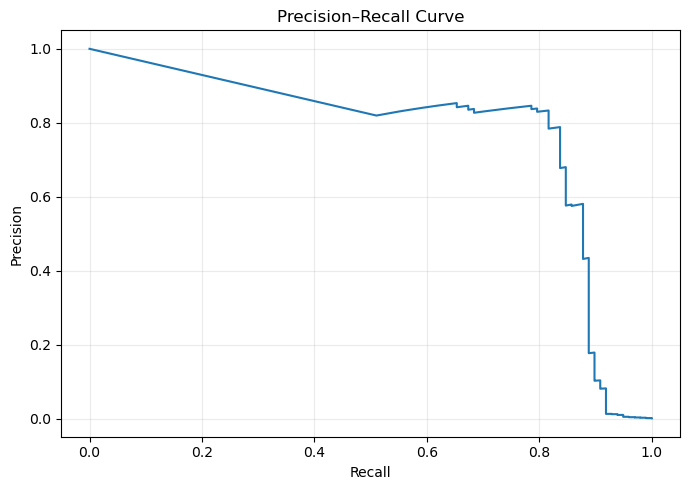

In [18]:
precision_values, recall_values, thresholds = precision_recall_curve(y_test, smote_prob)
plt.figure(figsize=(7,5)); plt.plot(recall_values, precision_values)
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision–Recall Curve'); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

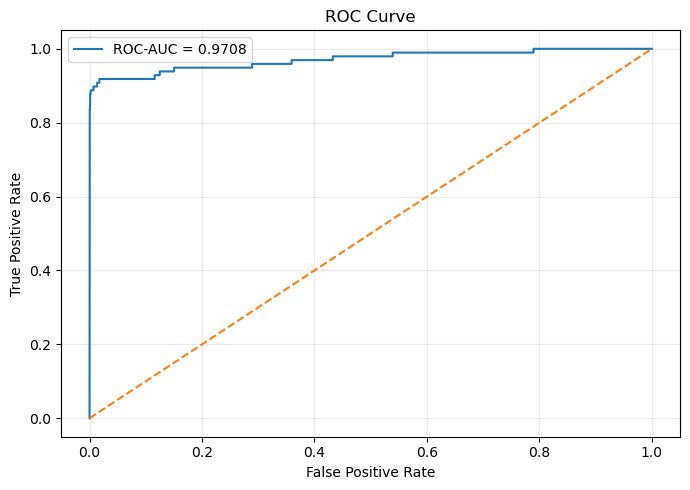

In [19]:
fpr, tpr, _ = roc_curve(y_test, smote_prob)
plt.figure(figsize=(7,5)); plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, smote_prob):.4f}"); plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve'); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

<a id="section8"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">8. Threshold Tuning</h2>

<style>.day5-card{background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}.day5-card p,.day5-card li,.day5-card td{color:#111111!important;}.day5-card table{width:100%;border-collapse:collapse;}.day5-card th{padding:9px;border:1px solid #CBD5E1;}.day5-card td{padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}</style><div class="day5-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">8.1 Choose a threshold deliberately</h3><p>There is no universally perfect threshold. It depends on the cost of false positives and false negatives.</p><p>For a clear technical example, the notebook finds the threshold with the best F1-score.</p><div style="border-left:5px solid #FBBF24;background-color:#FFFBEB;padding:11px 15px;margin:12px 0;border-radius:5px;color:#78350F;"><b>Fraud context:</b> if missing fraud is more costly than investigating a false alarm, a more recall-oriented threshold may be appropriate.</div></div>

In [20]:
p_thr = precision_values[:-1]
r_thr = recall_values[:-1]
f1_values = 2 * p_thr * r_thr / (p_thr + r_thr + 1e-12)
best_index = np.argmax(f1_values)
best_threshold = thresholds[best_index]
print(f'Best F1 threshold: {best_threshold:.4f}')
print(f'Precision: {p_thr[best_index]:.4f}')
print(f'Recall   : {r_thr[best_index]:.4f}')
print(f'F1       : {f1_values[best_index]:.4f}')

Best F1 threshold: 1.0000
Precision: 0.8333
Recall   : 0.8163
F1       : 0.8247


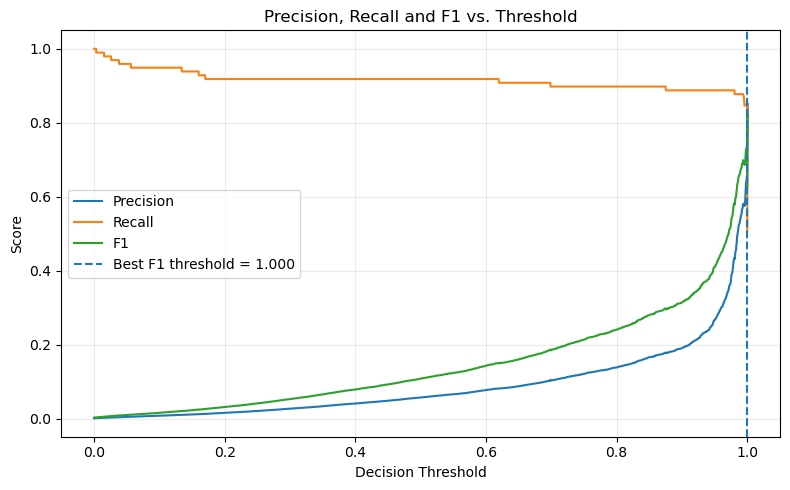

In [21]:
plt.figure(figsize=(8,5)); plt.plot(thresholds, p_thr, label='Precision'); plt.plot(thresholds, r_thr, label='Recall'); plt.plot(thresholds, f1_values, label='F1'); plt.axvline(best_threshold, linestyle='--', label=f'Best F1 threshold = {best_threshold:.3f}')
plt.xlabel('Decision Threshold'); plt.ylabel('Score'); plt.title('Precision, Recall and F1 vs. Threshold'); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

In [22]:
tuned_pred = (smote_prob >= best_threshold).astype(int)
tuned_metrics = evaluate_predictions(y_test, tuned_pred, smote_prob, 'SMOTE + Tuned Threshold')
final_comparison = pd.concat([baseline_metrics, smote_metrics, tuned_metrics], ignore_index=True)
display(final_comparison.style.format({c:'{:.4f}' for c in final_comparison.columns if c != 'Model'}))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline,0.9991,0.8267,0.6327,0.7168,0.9605,0.7414
1,SMOTE,0.9741,0.0578,0.9184,0.1088,0.9708,0.7245
2,SMOTE + Tuned Threshold,0.9994,0.8333,0.8163,0.8247,0.9708,0.7245


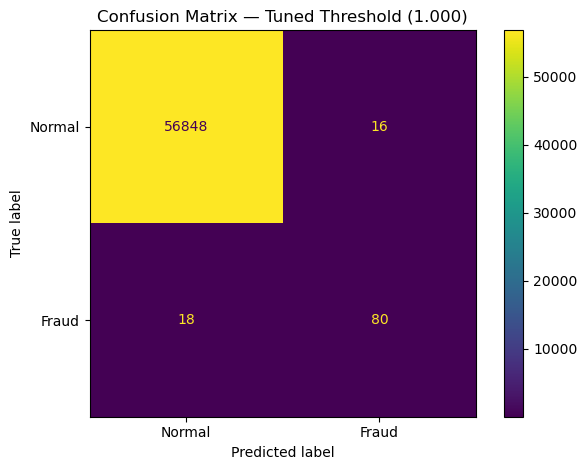

In [23]:
ConfusionMatrixDisplay.from_predictions(y_test, tuned_pred, display_labels=['Normal','Fraud'], values_format='d')
plt.title(f'Confusion Matrix — Tuned Threshold ({best_threshold:.3f})'); plt.tight_layout(); plt.show()

<a id="section9"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">9. SHAP Explainability</h2>

<style>.day5-card{background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}.day5-card p,.day5-card li,.day5-card td{color:#111111!important;}.day5-card table{width:100%;border-collapse:collapse;}.day5-card th{padding:9px;border:1px solid #CBD5E1;}.day5-card td{padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}</style><div class="day5-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">9.1 What is SHAP?</h3><p><b>SHAP — SHapley Additive exPlanations</b> estimates how much each feature pushes a model output up or down.</p><div style="background-color:#CCFBF1;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas,monospace;font-size:.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:10px 0;">Prediction
   ↓
SHAP
   ↓
Global explanation + One-prediction explanation</div><p>SHAP explains model behavior; it does not prove real-world causation.</p></div>

<style>.day5-card{background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}.day5-card p,.day5-card li,.day5-card td{color:#111111!important;}.day5-card table{width:100%;border-collapse:collapse;}.day5-card th{padding:9px;border:1px solid #CBD5E1;}.day5-card td{padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}</style><div class="day5-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">9.2 Prepare a practical SHAP sample</h3><p>We explain the fitted Logistic Regression component using the exact fitted scaler from the SMOTE pipeline. SHAP is limited to a small real sample to keep the notebook fast.</p></div>

In [24]:
fitted_scaler = smote_model.named_steps['scaler']
fitted_classifier = smote_model.named_steps['classifier']
X_train_scaled = pd.DataFrame(fitted_scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(fitted_scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
background = X_train_scaled.sample(n=min(500, len(X_train_scaled)), random_state=SEED)
explain_sample = X_test_scaled.sample(n=min(500, len(X_test_scaled)), random_state=SEED)
explainer = shap.Explainer(fitted_classifier, background)
shap_values = explainer(explain_sample)
print('SHAP values:', shap_values.values.shape)

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


SHAP values: (500, 30)


<a id="section10"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">10. Global Feature Importance</h2>

<style>.day5-card{background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}.day5-card p,.day5-card li,.day5-card td{color:#111111!important;}.day5-card table{width:100%;border-collapse:collapse;}.day5-card th{padding:9px;border:1px solid #CBD5E1;}.day5-card td{padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}</style><div class="day5-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">10.1 Which features matter most overall?</h3><p>The SHAP summary plot ranks features by their average impact across many predictions.</p></div>

C:\Users\sadee\AppData\Local\Temp\ipykernel_23544\3162740143.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, explain_sample, show=False)


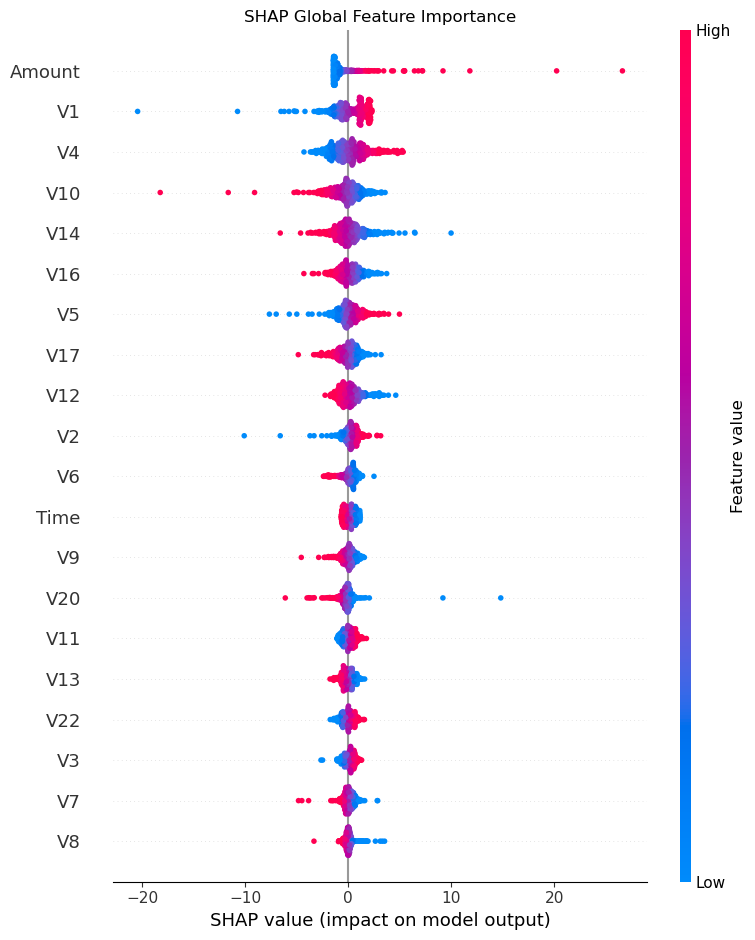

In [25]:
shap.summary_plot(shap_values, explain_sample, show=False)
plt.title('SHAP Global Feature Importance'); plt.tight_layout(); plt.show()

In [26]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
global_importance = pd.DataFrame({'feature': explain_sample.columns, 'mean_abs_shap': mean_abs_shap}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
display(global_importance.head(10))

,feature,mean_abs_shap
0,Amount,1.391588
1,V1,1.288110
2,V4,1.241225
3,V10,1.061104
4,V14,1.014267
5,V16,0.798172
6,V5,0.775222
7,V17,0.718169
8,V12,0.717851
9,V2,0.575949


<a id="section11"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">11. Explain One Prediction</h2>

<style>.day5-card{background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}.day5-card p,.day5-card li,.day5-card td{color:#111111!important;}.day5-card table{width:100%;border-collapse:collapse;}.day5-card th{padding:9px;border:1px solid #CBD5E1;}.day5-card td{padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}</style><div class="day5-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">11.1 Why THIS prediction?</h3><p>We choose one real test transaction and inspect which features pushed the model output higher or lower.</p></div>

In [27]:
sample_y = y_test.loc[explain_sample.index]
fraud_positions = np.where(sample_y.to_numpy() == 1)[0]
explanation_index = int(fraud_positions[0]) if len(fraud_positions) else 0
original_index = explain_sample.index[explanation_index]
actual_class = int(y_test.loc[original_index])
raw_row = X_test.loc[[original_index]]
fraud_probability = float(smote_model.predict_proba(raw_row)[0,1])
print('Actual class      :', actual_class)
print('Fraud probability :', f'{fraud_probability:.4f}')
print('Default prediction:', int(fraud_probability >= 0.50))
print('Tuned prediction  :', int(fraud_probability >= best_threshold))

Actual class      : 0
Fraud probability : 0.0026
Default prediction: 0
Tuned prediction  : 0


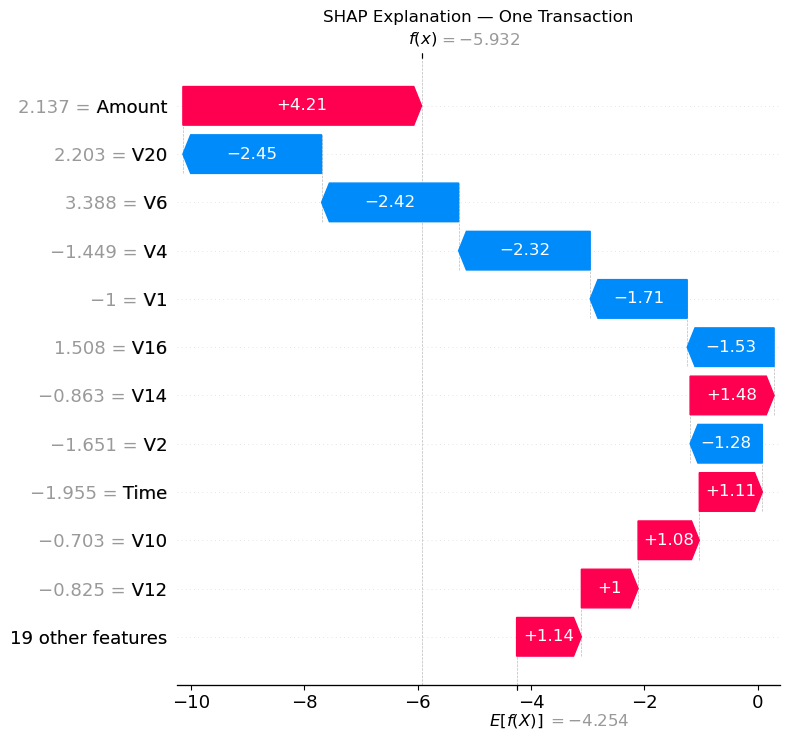

In [28]:
shap.plots.waterfall(shap_values[explanation_index], max_display=12, show=False)
plt.title('SHAP Explanation — One Transaction'); plt.tight_layout(); plt.show()

<style>.day5-card{background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}.day5-card p,.day5-card li,.day5-card td{color:#111111!important;}.day5-card table{width:100%;border-collapse:collapse;}.day5-card th{padding:9px;border:1px solid #CBD5E1;}.day5-card td{padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}</style><div class="day5-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">11.2 Read the explanation</h3><p>Positive SHAP values push the model output upward; negative SHAP values push it downward.</p><div style="border-left:5px solid #FBBF24;background-color:#FFFBEB;padding:11px 15px;margin:12px 0;border-radius:5px;color:#78350F;"><b>Important:</b> SHAP explains the model's reasoning pattern, not causal truth.</div></div>

<a id="section12"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">12. Final Technical Summary</h2>

In [29]:
technical_summary = final_comparison.copy()
for column in ['Accuracy','Precision','Recall','F1','ROC-AUC','PR-AUC']:
    technical_summary[column] = technical_summary[column].round(4)
display(technical_summary)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline,0.9991,0.8267,0.6327,0.7168,0.9605,0.7414
1,SMOTE,0.9741,0.0578,0.9184,0.1088,0.9708,0.7245
2,SMOTE + Tuned Threshold,0.9994,0.8333,0.8163,0.8247,0.9708,0.7245


<style>.day5-card{background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}.day5-card p,.day5-card li,.day5-card td{color:#111111!important;}.day5-card table{width:100%;border-collapse:collapse;}.day5-card th{padding:9px;border:1px solid #CBD5E1;}.day5-card td{padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}</style><div class="day5-card"><h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">12.1 What should we conclude?</h3><ul><li><b>Baseline</b> shows performance on the original imbalanced data.</li><li><b>SMOTE</b> changes training balance and can improve minority-class recall.</li><li><b>Threshold tuning</b> changes the decision rule without retraining.</li><li><b>SHAP</b> explains global and individual predictions.</li></ul><div style="border-left:5px solid #FBBF24;background-color:#FFFBEB;padding:11px 15px;margin:12px 0;border-radius:5px;color:#78350F;"><b>Final judgment:</b> choose the model and threshold using the task's metric priorities, not accuracy alone.</div></div>

<a id="section13"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">13. What I Learned Today</h2>

<style>.day5-card{background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}.day5-card p,.day5-card li,.day5-card td{color:#111111!important;}.day5-card table{width:100%;border-collapse:collapse;}.day5-card th{padding:9px;border:1px solid #CBD5E1;}.day5-card td{padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}</style><div class="day5-card"><ul><li><b>Task-appropriate evaluation:</b> Why classification needs more than accuracy.</li><li><b>Precision:</b> How reliable fraud predictions are.</li><li><b>Recall:</b> How many real fraud cases are detected.</li><li><b>F1-score:</b> How precision and recall are balanced.</li><li><b>ROC-AUC:</b> Ranking quality across thresholds.</li><li><b>PR-AUC:</b> Positive-class performance under imbalance.</li><li><b>Class imbalance:</b> Why fraud detection has very few positive cases.</li><li><b>SMOTE:</b> How synthetic minority samples rebalance training data.</li><li><b>Data leakage prevention:</b> Why SMOTE is applied only after the split and only to training data.</li><li><b>Precision–recall trade-off:</b> Why improving one may reduce the other.</li><li><b>Threshold tuning:</b> How the decision threshold changes missed fraud vs. false alarms.</li><li><b>SHAP:</b> How feature contributions explain model predictions.</li><li><b>Global explanation:</b> Which features matter most overall.</li><li><b>Per-prediction explanation:</b> Why one transaction received its prediction.</li></ul></div>

<a id="section14"></a><h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">14. Day 5 Mental Map</h2>

<style>.day5-card{background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;}.day5-card p,.day5-card li,.day5-card td{color:#111111!important;}.day5-card table{width:100%;border-collapse:collapse;}.day5-card th{padding:9px;border:1px solid #CBD5E1;}.day5-card td{padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;}</style><div class="day5-card"><div style="background-color:#CCFBF1;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas,monospace;font-size:.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:10px 0;">CREDIT CARD TRANSACTIONS
        ↓
TRAIN / TEST SPLIT
        ↓
BASELINE MODEL
        ↓
FULL EVALUATION
Precision • Recall • F1 • ROC-AUC • PR-AUC
        ↓
CLASS IMBALANCE
        ↓
SMOTE — TRAINING ONLY
        ↓
COMPARE RESULTS
        ↓
PRECISION–RECALL TRADE-OFF
        ↓
THRESHOLD TUNING
        ↓
FINAL PREDICTIONS
        ↓
SHAP EXPLAINABILITY
   ┌───────────────┐
   ↓               ↓
Global          Individual
Importance      Explanation</div><div style="border-left:5px solid #FBBF24;background-color:#FFFBEB;padding:11px 15px;margin:12px 0;border-radius:5px;color:#78350F;"><b>Day 5 in one sentence:</b> Evaluate the fraud model with the right metrics, handle imbalance carefully, tune the decision threshold, and explain predictions with SHAP.</div></div>

<div style="text-align:center;margin-top:28px;color:#475569;"><b>End of Day 5 — Full Evaluation & Explainability</b><br>Imbalanced fraud data → correct metrics → SMOTE → threshold tuning → SHAP</div>